In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import nltk, random, numpy, os
import matplotlib.pyplot as plt
from typing import List
os.makedirs('./results', exist_ok=True)
nltk.download('brown')
random.seed(42)
torch.manual_seed(42)
numpy.random.seed(42)
brown = nltk.corpus.brown.words()


[nltk_data] Downloading package brown to /Users/myriam/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


### Introduction
In the warm-up of this assignment, we will see how Neural Networks (NN) handle natural language data.   
The warm-up focuses on a simple Multilayer Perceptron (MLP), also known as a fully connected Neural Network. The data we'll use is the first 5000 unique words of the Brown corpus.

### Dataset
To train the model, we will have to represent the input words to the model in some way. Since models solely work with numbers, the words will have to be converted into numerical form.  
For this assignment, we will focus on predicting individual words from the dataset given the input of the model. The input will be the target word split up into individual letters. To represent these individual letters we will give the model a vector of 26 positions (26 letters in the English alphabet). Initially, this vector is filled with zeros and for every occuring letter in the word we change the value to 1 in that position. For instance, in the word `apple', we have 1 a, 1 e, 1 l and 2 p. The vector will then represent the word as:  
```[1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0]```  
You will have to implement this algorithm together with loading the Brown dataset and taking the first 5000 unique words. Implement a way to store the indexes of the unique words as a dictionary where the word is the key and the index is the value as well as the target list (which will be just the indexes of the words).

In [2]:
class AlphaDataset(Dataset):
    def __init__(self) -> None:
        # Load the NLTK Brown corpus and store the first 5000 unique words of the corpus in self.data
        brown_lower_alpha = [word.lower() for word in brown if word.isalpha()]
        seen = {}
        for word in brown_lower_alpha:
            if word not in seen:
                seen[word] = len(seen)
            if len(seen) == 5000:
                break

        self.word_to_idx = seen
        self.data = list(seen.keys())
        self.targets = list(seen.values())

        # Precompute the 26-dim letter-count vector for every word once,
        # instead of recomputing it on every __getitem__ call / every epoch.
        self.vectors = []
        for word in self.data:
            counts = [0] * 26
            for letter in word:
                counts[ord(letter) - ord('a')] += 1  # O(1) index, no list rebuild
            self.vectors.append(torch.tensor(counts, dtype=torch.float32))

    def __len__(self) -> int:
        # Torch requires length func
        return len(self.data)

    def __getitem__(self, index):
        x = self.vectors[index]
        y = torch.tensor(self.targets[index], dtype=torch.long)
        return x, y


### Multilayer Perceptron
In the following section, you will implement a MLP. The goal is to implement this MLP with 1 input layer, 2 hidden layers, and 1 output layer.
With PyTorch, the linear layer is most suitable for this. When you create a linear layer, you define the input and output size of the layer, effectively creating two linear neuron layers. This is useful to know since we only need to create 3 linear layer classes to have the 4 layers we want.
The hidden size is stored as a list where the first value will be 256 and the second value will be 512.

In [3]:
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: List[int], output_size: int) -> None:
        super().__init__()
        # Implement the neural network layers, the activation function is already defined
        self.input_layer = nn.Linear(input_size, hidden_size[0])
        self.hidden_layer = nn.Linear(hidden_size[0], hidden_size[1])
        self.output_layer = nn.Linear(hidden_size[1], output_size)

        self.activation = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # In the forward pass the model will calculate the gradients as well as the probabilities of the result occuring given its input.
        x = self.input_layer(x)
        x = self.activation(x)
        x = self.hidden_layer(x)
        x = self.activation(x)
        x = self.output_layer(x)

        return x

### Setting up the hyperparameters
These are the hyperparameters used for the model, they define the layout of the model as well as the performance:
- batch_size, defines the number of instances the model sees at one time.
- learning_rate, defines the change rate of the gradient descent.
- input_size, the number of input neurons for the model, the number of letters in the alphabet
- hidden_size, the number of neurons in the hidden layer
- output_size, the number of neurons in the output layer, for us this is the number of unqiue words

In [4]:
batch_size = 8
learning_rate = 1e-5
input_size = 26
hidden_size = [256, 512]
output_size = 5000
device = 'mps' # If you have an m1 macbook use: 'mbp', if you have an NVIDIA GPU use: 'cuda:0' else leave as is

Setting up the dataset

In [5]:
# Define the dataset and the dataloader
dataset = AlphaDataset()

# For the final evaluation of the model we will use 20% of the data for testing. Testing is only ever done after hyperparameter tuning.
# Split sizes (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# To evaluate our model we want to take 10% of the dataset for validation, this is similar to the testset, rather this data we can use during hyperparameter tuning.
# The validation and test data is never trained on and is unseen data for the model, making it closer to a production setting.
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) # Shuffling ensures the model does not overfit on ordering of the data.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # This data does not need to be shuffled
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  #T his data does not need to be shuffled

### Preperation for training
Here we load the model into memory, apply it to the selected device and define the optimizer. The optimizer guides the model to the best possible state it can be in through Gradient descent.
Lastly, the loss function is defined, this defines how well the model performs, based on this number the model knows how it should change its weights.

In [7]:
model = MLP(input_size, hidden_size, output_size)
model.to(device) # Tell de model which accelerator to use (Macbook GPU, NVIDIA GPU or CPU)

# In Neural Networks optimizers handle the efficient training through gradient descent, we will use Adam
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

# The loss function defines how well the model is performing, if the loss is low the model is rewarded, if it is high the model is punished.
# Since we are dealing with a classification task we will use Cross Entropy
loss_fn = nn.CrossEntropyLoss()

### Training
In the next block the training block is already defined. This is a standard way to train the model for 50 epochs (50 times it will see the dataset). Each time it does one epoch we also go over the validationset.

In [8]:
training_losses = []
validation_losses = []

for epoch in range(50): # Train for 50 epochs
    model.train() # Enforce model training
    epoch_train_loss = 0
    for step, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        training_losses.append(loss.item())   # per-step loss, used for the training-loss plot
        epoch_train_loss += loss.item()
        # print(loss.item(), end='\r')

        loss.backward() # Calculate gradients

        optimizer.step() # Reward the model
        optimizer.zero_grad() # Clean the gradients
    # Average over the epoch, not just the last batch.
    print('Training_loss:', epoch_train_loss / len(train_loader))

    model.eval() # After every training epoch we want to see the model's performance on the validation data
    with torch.no_grad(): # In validation we dont need gradients so we tell torch to not calculate them
        total_val_loss = 0
        for step, (x, y) in enumerate(val_loader):
            x = x.to(device)
            y = y.to(device)

            output = model(x)

            loss = loss_fn(output, y)

            total_val_loss += loss.item()

        # loss_fn uses reduction='mean', so each loss.item() is already a per-batch mean.
        # Average over the number of batches (len(val_loader)), NOT the number of samples.
        validation_losses.append(total_val_loss / len(val_loader))
        print('Validation_loss:', validation_losses[-1])


Training_loss: 8.533391327328152
Validation_loss: 8.558078327178954
Training_loss: 8.46085555182563
Validation_loss: 8.647813510894775
Training_loss: 8.373616746266682
Validation_loss: 8.801983013153077
Training_loss: 8.24729449166192
Validation_loss: 9.064105644226075
Training_loss: 8.096469223234388
Validation_loss: 9.444333152770996
Training_loss: 7.946970044242011
Validation_loss: 9.900906314849854
Training_loss: 7.812082299126519
Validation_loss: 10.387920780181885
Training_loss: 7.690855055914985
Validation_loss: 10.878918857574464
Training_loss: 7.578194563123915
Validation_loss: 11.366999340057372
Training_loss: 7.469157031377157
Validation_loss: 11.854375190734864
Training_loss: 7.360084310107761
Validation_loss: 12.34621503829956
Training_loss: 7.249360740449694
Validation_loss: 12.848084678649903
Training_loss: 7.136643469068739
Validation_loss: 13.36573398590088
Training_loss: 7.021795279184977
Validation_loss: 13.899952735900879
Training_loss: 6.904202772776286
Validation_

### Writing
Below we can print the training statistics, the training loss should be going down while the validation loss should be going up. What does it mean that the validation loss increases?

Looking at the plots below it can be seen that the training loss steadily drops from ~8.5 to ~2.7 over 50 epochs. This indicates that the model seem to be learning the training data. But the validation loss goes the other way the entire time, from ~8.6 up to ~39.5, meaning none of that learning transfers to unseen words. Since the mapping from letter counts to word indices is arbitrary, the model just memorizes the training set and has nothing useful to apply to new words


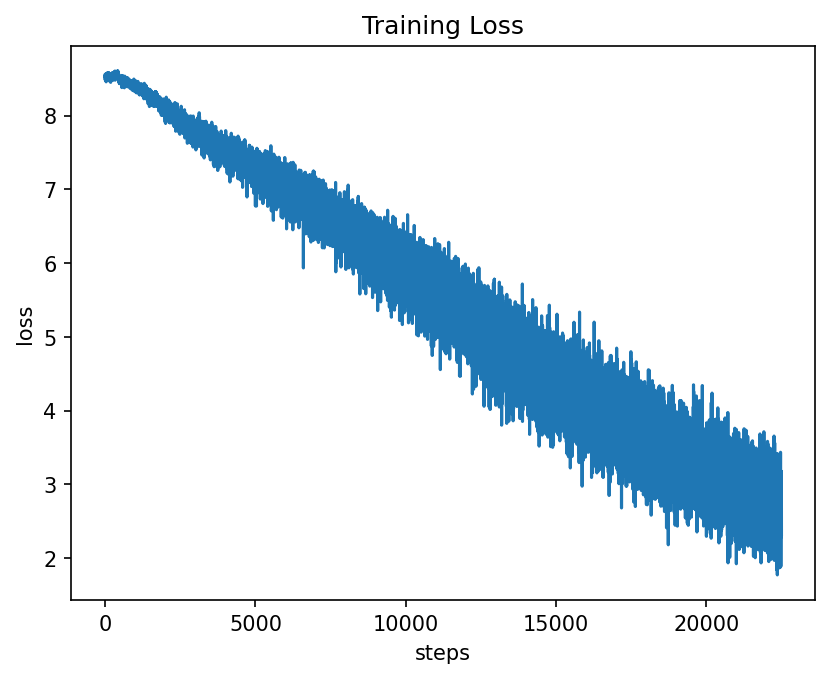

In [9]:
plt.rcParams['figure.dpi'] = 150
plt.plot(training_losses)
plt.xlabel('steps')
plt.ylabel('loss')
plt.title('Training Loss')
plt.savefig('./results/training_loss.png')

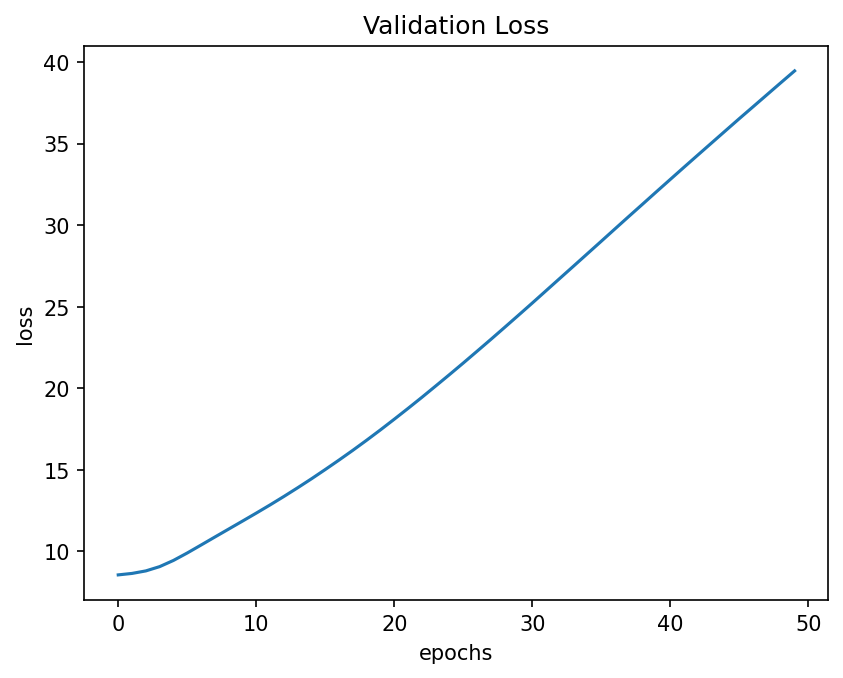

In [10]:
plt.plot(validation_losses)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Validation Loss')
plt.savefig('./results/validation_loss.png')


### Writing
Belowe we want to analyze how the model functions based on the test data. What stands out from these results? Was the result correct? What is the main difference between the words?

None of the 10 test predictions is correct. What stands out is that each prediction shares almost the same letters (and letter counts) as its target, e.g. target `composition` -> `motions`, where every letter of the prediction also occurs in the target. The model only has letter counts to work with, so for test words it just picks whichever training word has similar letters. The predictions and targets look alike letter-wise but have completely different meaning. 


In [11]:
def get_n_words(dataset, n, model, ds, verbose = True):
    if n == -1:
        n = len(dataset)
    x = [dataset[i][0].to(device) for i in range(n)]
    y = [dataset[i][1].to(device) for i in range(n)]

    # Build the index -> word lookup once, instead of rebuilding it for every word.
    idx_to_word = {idx: word for word, idx in ds.word_to_idx.items()}
    target_words = [idx_to_word[_.item()] for _ in y]

    model.eval()
    with torch.no_grad():
        # argmax of the logits is identical to argmax after softmax, so softmax is unnecessary.
        out = [model(wrd).argmax() for wrd in x]
    predicted_words = [idx_to_word[_.item()] for _ in out]

    width = max(len(word) for word in target_words) + 5
    if verbose:
        print('\n'.join([f'target: {t.ljust(width)} predicted: {p}' for t, p in zip(target_words, predicted_words)]))
    return target_words, predicted_words

_,_ = get_n_words(test_dataset, 10, model, dataset)


target: composition      predicted: opposition
target: division         predicted: dividing
target: widely           predicted: killed
target: accepting        predicted: practicing
target: indemnity        predicted: imminent
target: polls            predicted: follows
target: succeeds         predicted: succeed
target: pardoned         predicted: road
target: honest           predicted: sexton
target: poll             predicted: loophole


Why are some words incorrectly predicted?

None of these were predicted correctly because the model only gets a 26-dimensional letter-count vector as input, while the target index is just the order the word appeared in the corpus. There's no real relationship between letter counts and word indices, so the model has no way to figure out the right index for a word it hasn't seen during training. Moreover, different words can have identical or near-identical letter counts (e.g. anagrams), so the mapping isn't always unique.


### Code + Written
Research the Jaccard similarity metric for calculating the difference between the predicted word and the target word. Reference your sources and implement this metric in your code below. You can use the get_n_words function with n=-1 to get all the predicted and target words. Compare this method to similarity as measured with one of the word vector methods from A2, in writing and/or code.

References:
https://www.geeksforgeeks.org/data-science/how-to-calculate-jaccard-similarity-in-python
https://www.ibm.com/think/topics/jaccard-similarity#:~:text=Jaccard%20similarity%20is%20a%20statistical,that%20the%20sets%20are%20identical.


In [ ]:
# Method 1: 
def jaccard_similarity(s1, s2):
    a, b = set(s1), set(s2)
    return len(a & b) / len(a | b) # intersection / union

# Use n=-1 to evaluate over the whole test set, as suggested in the instructions.
tgs, preds = get_n_words(test_dataset, -1, model, dataset, verbose=False)
sims = [jaccard_similarity(tg, pred) for tg, pred in zip(tgs, preds)]

# Show a few examples...
for tg, pred, sim in list(zip(tgs, preds, sims))[:10]:
    print(tg, pred, round(sim, 4))

# ...and the summary statistic that makes the comparison to cosine meaningful.
print(f'\nMean Jaccard similarity over {len(sims)} test words: {sum(sims) / len(sims):.4f}')


In [ ]:
# Method 2: cosine similarity with A2's word-vector method (pretrained GloVe via gensim).
# Same model as A2: glove-wiki-gigaword-200 (cached on disk after A2's first download).
# If gensim isn't installed in this kernel, run once:  %pip install gensim
import numpy as np
import gensim.downloader as api

wv = api.load("glove-wiki-gigaword-200")   # loads from local cache if already downloaded

def glove_cosine(w1, w2):
    # GloVe vocab is lowercase; return None if either word is out of vocabulary.
    if w1 in wv and w2 in wv:
        return float(wv.similarity(w1, w2))
    return None

cos = [glove_cosine(t, p) for t, p in zip(tgs, preds)]   # reuse the pairs/scores from above

print(f"{'target':16}{'predicted':16}{'jaccard':>9}{'cosine':>9}")
shown = 0
for t, p, j, c in zip(tgs, preds, sims, cos):
    if c is None:
        continue
    print(f"{t:16}{p:16}{j:9.3f}{c:9.3f}")
    shown += 1
    if shown == 10:
        break

both = [(j, c) for j, c in zip(sims, cos) if c is not None]
mean_j = sum(j for j, _ in both) / len(both)
mean_c = sum(c for _, c in both) / len(both)
print(f"\nPairs with both words in GloVe vocab: {len(both)}/{len(cos)}")
print(f"Mean Jaccard (character overlap): {mean_j:.4f}")
print(f"Mean cosine  (GloVe semantics):   {mean_c:.4f}")


In A2 we used cosine similarity on pretrained GloVe vectors (glove-wiki-gigaword-200) to compare words by meaning. GloVe learns from which words tend to appear near each other in text, so cosine between two GloVe vectors tells you how semantically close they are. Jaccard similarity does something completely different: it just looks at which letters the two words share.

The code cell above computes both scores for every (target, prediction) pair in the test set. The mean Jaccard comes out high, which makes sense because the MLP only receives a letter-count vector as input, so it ends up predicting a training word that has similar letters. The mean cosine is a lot lower because sharing letters says nothing about meaning (e.g. composition and motions overlap in letters but are not related semantically).

So Jaccard is the better metric for evaluating this model specifically, since it measures exactly the kind of similarity the model is working with. Cosine would matter if the model had any access to word meaning, but it does not.